---
Phase 1-3: K-Nearest Neighbors (KNN)
---

最直覺的分類方式：
  「看看離你最近的 K 個鄰居是什麼類別，多數決」

不需要「訓練」！(Lazy Learning)
  - 沒有 w, b 這些參數要學
  - 預測時直接拿訓練資料來比較
  - 缺點：預測速度慢（要和所有訓練樣本比較距離）

本檔涵蓋：
  Part A: 距離度量的概念
  Part B: NumPy 手刻 KNN
  Part C: Scikit-learn 版
  Part D: K 值的影響

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Part A: 距離度量
# ============================================================================

In [2]:
print("=" * 60)
print("Part A: 距離度量 — 怎麼定義「近」")
print("=" * 60)

p1 = np.array([1, 2])
p2 = np.array([4, 6])

# 歐氏距離 (Euclidean Distance) — L2
euclidean = np.sqrt(np.sum((p1 - p2) ** 2))
# 等同 np.linalg.norm(p1 - p2)
print(f"p1 = {p1}, p2 = {p2}")
print(f"歐氏距離 (L2): √((4-1)² + (6-2)²) = √(9+16) = {euclidean:.4f}")

# 曼哈頓距離 (Manhattan Distance) — L1
manhattan = np.sum(np.abs(p1 - p2))
print(f"曼哈頓距離 (L1): |4-1| + |6-2| = {manhattan}")

# 在高維空間中，距離會出現「維度詛咒」
# 維度越高，所有點之間的距離都變得差不多，KNN 就不太好用
print(f"""
距離的選擇：
  低維資料（特徵 < 20）  → 歐氏距離通常 OK
  高維資料（特徵很多）    → 需要先降維（PCA），或用其他算法
  文字 / 類別特徵        → 可能需要餘弦相似度 (Cosine Similarity)
""")

Part A: 距離度量 — 怎麼定義「近」
p1 = [1 2], p2 = [4 6]
歐氏距離 (L2): √((4-1)² + (6-2)²) = √(9+16) = 5.0000
曼哈頓距離 (L1): |4-1| + |6-2| = 7

距離的選擇：
  低維資料（特徵 < 20）  → 歐氏距離通常 OK
  高維資料（特徵很多）    → 需要先降維（PCA），或用其他算法
  文字 / 類別特徵        → 可能需要餘弦相似度 (Cosine Similarity)



## Part B: NumPy 手刻 KNN

In [3]:
print("=" * 60)
print("Part B: NumPy 手刻 KNN")
print("=" * 60)

# --- 生成資料 ---
np.random.seed(42)

# 3 個類別，每個 50 個樣本
centers = [[-2, -2], [0, 2], [2, -1]]
X_list, y_list = [], []
for i, center in enumerate(centers):
    X_list.append(np.random.randn(50, 2) * 0.8 + center)
    y_list.append(np.full(50, i))

X = np.vstack(X_list)
y = np.concatenate(y_list)

# 打亂 & 切分
idx = np.random.permutation(len(y))
X, y = X[idx], y[idx]
X_train, X_test = X[:120], X[120:]
y_train, y_test = y[:120], y[120:]

print(f"訓練集: {X_train.shape[0]} 樣本")
print(f"測試集: {X_test.shape[0]} 樣本")


class KNN_Numpy:
    """NumPy 手刻的 KNN 分類器"""

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # KNN 不需要「訓練」，只是記住資料
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x in X:
            # 1. 算這個點和所有訓練樣本的距離
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

            # 2. 找最近的 K 個鄰居
            k_nearest_idx = distances.argsort()[:self.k]
            k_nearest_labels = self.y_train[k_nearest_idx]

            # 3. 多數決
            counts = np.bincount(k_nearest_labels)
            predictions.append(counts.argmax())

        return np.array(predictions)


# 訓練 & 預測
knn = KNN_Numpy(k=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"\nNumPy KNN (k=5) 測試準確率: {accuracy:.2%}")

# 看看分類細節
print(f"\n前 10 個測試樣本:")
print(f"  {'真實':>4s}  {'預測':>4s}  {'正確':>4s}")
for i in range(10):
    correct = "V" if y_pred[i] == y_test[i] else "X"
    print(f"  {y_test[i]:4d}  {y_pred[i]:4d}  {correct:>4s}")


# 向量化版本（更快）
class KNN_Vectorized:
    """向量化版本，避免 Python for 迴圈"""

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        # 用矩陣運算一次算出所有距離
        # ||a - b||² = ||a||² + ||b||² - 2aᵀb
        # shape: (n_test, n_train)
        dists = (
            np.sum(X ** 2, axis=1, keepdims=True)      # (n_test, 1)
            + np.sum(self.X_train ** 2, axis=1)         # (n_train,)
            - 2 * X @ self.X_train.T                    # (n_test, n_train)
        )
        dists = np.sqrt(np.maximum(dists, 0))   # 防止浮點誤差導致負數

        # 找每個測試樣本的 K 個最近鄰
        k_nearest = np.argsort(dists, axis=1)[:, :self.k]

        # 多數決
        k_labels = self.y_train[k_nearest]      # (n_test, k)
        predictions = np.array([np.bincount(row, minlength=3).argmax()
                                for row in k_labels])
        return predictions


knn_v = KNN_Vectorized(k=5)
knn_v.fit(X_train, y_train)
y_pred_v = knn_v.predict(X_test)
print(f"\n向量化 KNN 準確率: {np.mean(y_pred_v == y_test):.2%}")
print(f"兩版結果相同: {np.all(y_pred == y_pred_v)}")

Part B: NumPy 手刻 KNN
訓練集: 120 樣本
測試集: 30 樣本

NumPy KNN (k=5) 測試準確率: 96.67%

前 10 個測試樣本:
    真實    預測    正確
     2     2     V
     1     1     V
     1     1     V
     1     1     V
     1     1     V
     0     0     V
     1     1     V
     0     0     V
     1     1     V
     1     1     V

向量化 KNN 準確率: 96.67%
兩版結果相同: True


## Part C: Scikit-learn 版


Part C: Scikit-learn 版


sklearn KNN (k=5) 準確率: 96.67%
和手刻版結果相同: True


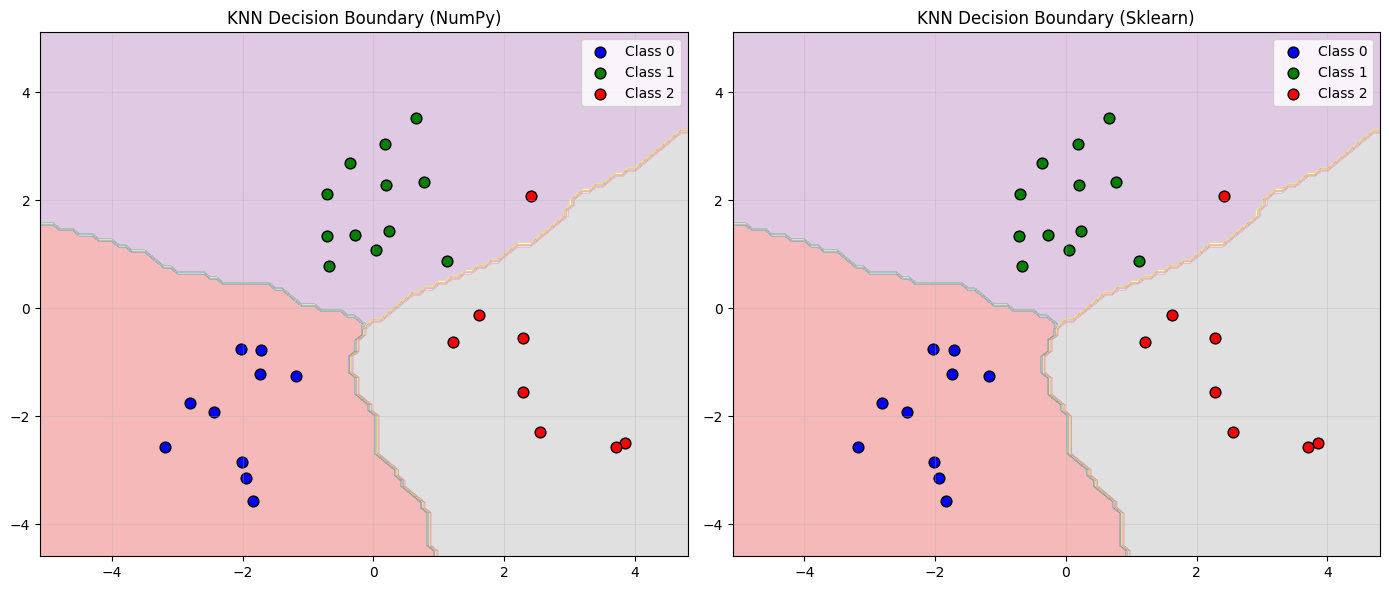

→ 圖表儲存至 plots/03_knn_boundary.png


In [4]:
print("\n" + "=" * 60)
print("Part C: Scikit-learn 版")
print("=" * 60)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

y_pred_sk = clf.predict(X_test)
print(f"sklearn KNN (k=5) 準確率: {clf.score(X_test, y_test):.2%}")
print(f"和手刻版結果相同: {np.all(y_pred == y_pred_sk)}")

# 畫決策邊界
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, pred) in zip(axes, [("NumPy", y_pred), ("Sklearn", y_pred_sk)]):
    # 畫決策邊界（用網格預測）
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    if name == "NumPy":
        Z = knn_v.predict(grid)
    else:
        Z = clf.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    colors = ['blue', 'green', 'red']
    for c in range(3):
        mask = y_test == c
        ax.scatter(X_test[mask, 0], X_test[mask, 1], c=colors[c],
                   s=60, edgecolors='k', label=f'Class {c}')
    ax.set_title(f'KNN Decision Boundary ({name})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/03_knn_boundary.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/03_knn_boundary.png")

## Part D: K 值的影響

In [5]:
print("\n" + "=" * 60)
print("Part D: K 值的影響")
print("=" * 60)

k_values = [1, 3, 5, 7, 9, 15, 25, 50]
accuracies = []

print(f"{'K':>4s}  {'Accuracy':>10s}  說明")
print("-" * 40)

for k in k_values:
    clf_k = KNeighborsClassifier(n_neighbors=k)
    clf_k.fit(X_train, y_train)
    acc = clf_k.score(X_test, y_test)
    accuracies.append(acc)

    note = ""
    if k == 1:
        note = "← 容易過擬合（只看最近 1 個）"
    elif k == 50:
        note = "← 容易欠擬合（看太多鄰居）"
    print(f"{k:4d}  {acc:10.2%}  {note}")

print(f"""
K 值的選擇：
  K 太小 (如 1) → 模型太敏感，受噪音影響大 → 過擬合
  K 太大 (如 N) → 模型太粗糙，全部預測多數類 → 欠擬合
  通常選奇數（避免平票），用交叉驗證找最佳 K
""")


Part D: K 值的影響
   K    Accuracy  說明
----------------------------------------
   1      96.67%  ← 容易過擬合（只看最近 1 個）
   3      96.67%  
   5      96.67%  
   7      96.67%  
   9      96.67%  
  15      96.67%  
  25      96.67%  
  50      96.67%  ← 容易欠擬合（看太多鄰居）

K 值的選擇：
  K 太小 (如 1) → 模型太敏感，受噪音影響大 → 過擬合
  K 太大 (如 N) → 模型太粗糙，全部預測多數類 → 欠擬合
  通常選奇數（避免平票），用交叉驗證找最佳 K



## 小結

In [6]:
print("=" * 60)
print("小結")
print("=" * 60)
print("""
KNN 教會你的核心概念：

  概念               對應到深度學習
  ──────────────────────────────────────────────
  距離度量           →  Embedding 空間中的相似度計算
  K 的選擇           →  超參數調整的概念
  過擬合/欠擬合      →  模型複雜度 vs 泛化能力
  維度詛咒           →  為什麼需要 Embedding / 降維
  Lazy Learning      →  vs 深度學習的 Eager Learning

KNN 的優缺點：
  優點：簡單直覺、不需訓練、適合小資料集
  缺點：預測慢、高維效果差、需要存所有訓練資料

sklearn 速查：
  from sklearn.neighbors import KNeighborsClassifier
  clf = KNeighborsClassifier(n_neighbors=5)
  clf.fit(X_train, y_train)
  clf.predict(X_test)

下一步：04_decision_tree.py — 非線性模型 + 集成學習
""")

小結

KNN 教會你的核心概念：

  概念               對應到深度學習
  ──────────────────────────────────────────────
  距離度量           →  Embedding 空間中的相似度計算
  K 的選擇           →  超參數調整的概念
  過擬合/欠擬合      →  模型複雜度 vs 泛化能力
  維度詛咒           →  為什麼需要 Embedding / 降維
  Lazy Learning      →  vs 深度學習的 Eager Learning

KNN 的優缺點：
  優點：簡單直覺、不需訓練、適合小資料集
  缺點：預測慢、高維效果差、需要存所有訓練資料

sklearn 速查：
  from sklearn.neighbors import KNeighborsClassifier
  clf = KNeighborsClassifier(n_neighbors=5)
  clf.fit(X_train, y_train)
  clf.predict(X_test)

下一步：04_decision_tree.py — 非線性模型 + 集成學習

